# NFL 4th Down Analysis — EDA
Exploratory data analysis of 4th down decisions across all available nflfastR seasons (1999–2024).

**Goals:**
- Understand the dataset shape and decision distribution
- Identify league-wide trends in 4th down aggressiveness over time
- Spot data quality issues before modeling
- Generate charts for the blog post intro

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_all_seasons, filter_fourth_downs, add_recency_weights
from grading import league_4th_down_summary

# Plot style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

SAVE_DIR = '../outputs/figures/'

## 1. Load Data

In [2]:
# Load all seasons — downloads once, caches as parquet for fast re-use
pbp = load_all_seasons(first=1999, last=2025)
fourth = filter_fourth_downs(pbp)
fourth = add_recency_weights(fourth)

print(f'\nDataset shape: {fourth.shape}')
fourth.head(3)

Loading seasons 1999–2024...

Total plays loaded: 1,230,857
4th down plays: 103,188 across 26 seasons
Decision breakdown:
decision
punt          64095
field_goal    24431
go_for_it     14662
Name: count, dtype: int64

Dataset shape: (103188, 43)


,play_id,game_id,season,week,game_date,posteam,defteam,home_team,away_team,down,...,vegas_wp,vegas_home_wp,roof,surface,temp,wind,spread_line,total_line,decision,recency_weight
0,150,1999_01_ARI_PHI,1999,1,1999-09-12,PHI,ARI,PHI,ARI,4.0,...,0.326737,0.326737,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618
1,240,1999_01_ARI_PHI,1999,1,1999-09-12,ARI,PHI,PHI,ARI,4.0,...,0.589322,0.410678,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618
2,561,1999_01_ARI_PHI,1999,1,1999-09-12,ARI,PHI,PHI,ARI,4.0,...,0.362009,0.637991,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618


## 2. Decision Distribution

In [3]:
# Overall breakdown
decision_counts = fourth['decision'].value_counts()
decision_pct = fourth['decision'].value_counts(normalize=True) * 100

print('Decision breakdown (all seasons):')
for d in decision_counts.index:
    print(f'  {d:15s}: {decision_counts[d]:6,} plays ({decision_pct[d]:.1f}%)')

Decision breakdown (all seasons):
  punt           : 64,095 plays (62.1%)
  field_goal     : 24,431 plays (23.7%)
  go_for_it      : 14,662 plays (14.2%)


## 3. Go-For-It Rate Over Time
This is the headline chart — shows the NFL's growing aggressiveness over 25 years.

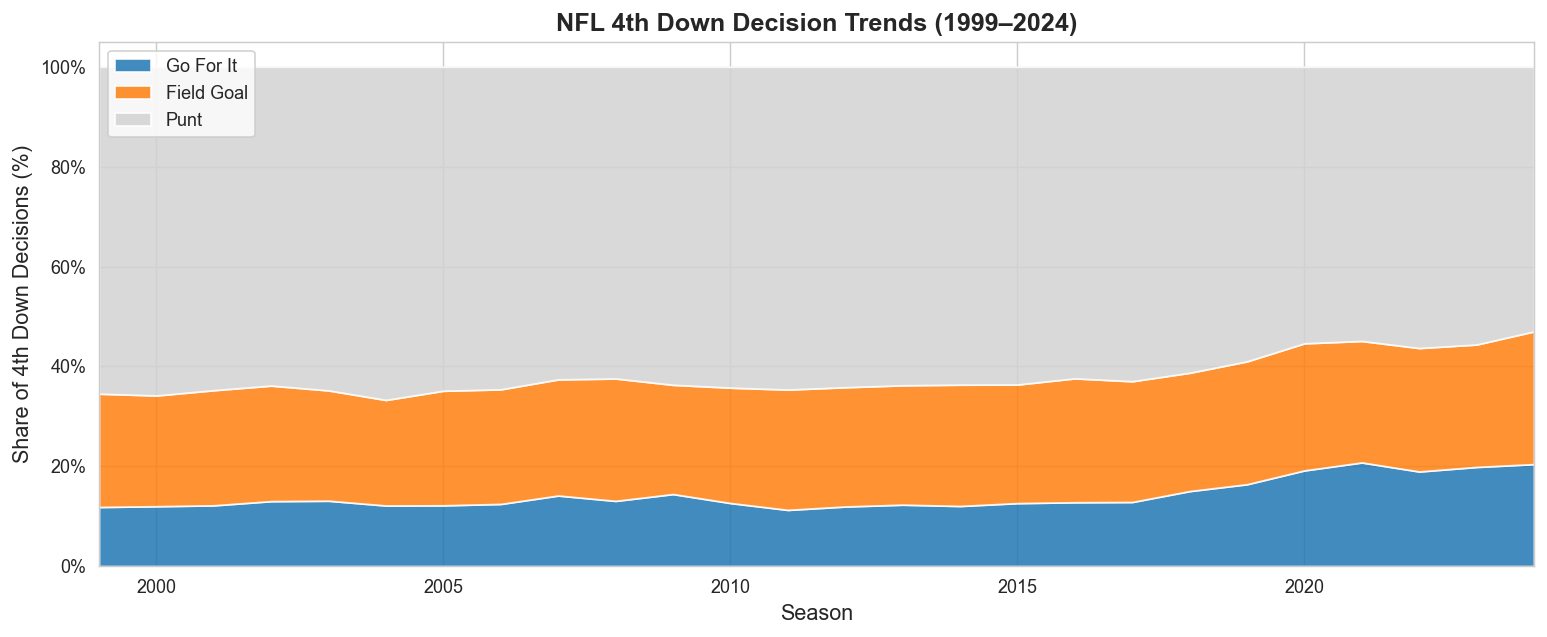

In [4]:
summary = league_4th_down_summary(fourth)

fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(
    summary['season'],
    summary['go_rate'] * 100,
    summary['fg_rate'] * 100,
    summary['punt_rate'] * 100,
    labels=['Go For It', 'Field Goal', 'Punt'],
    colors=['#1f77b4', '#ff7f0e', '#d3d3d3'],
    alpha=0.85,
)

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Share of 4th Down Decisions (%)', fontsize=12)
ax.set_title('NFL 4th Down Decision Trends (1999–2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(1999, 2024)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}01_decision_trends.png', bbox_inches='tight')
plt.show()

## 4. Go-For-It Rate by Field Position and Distance

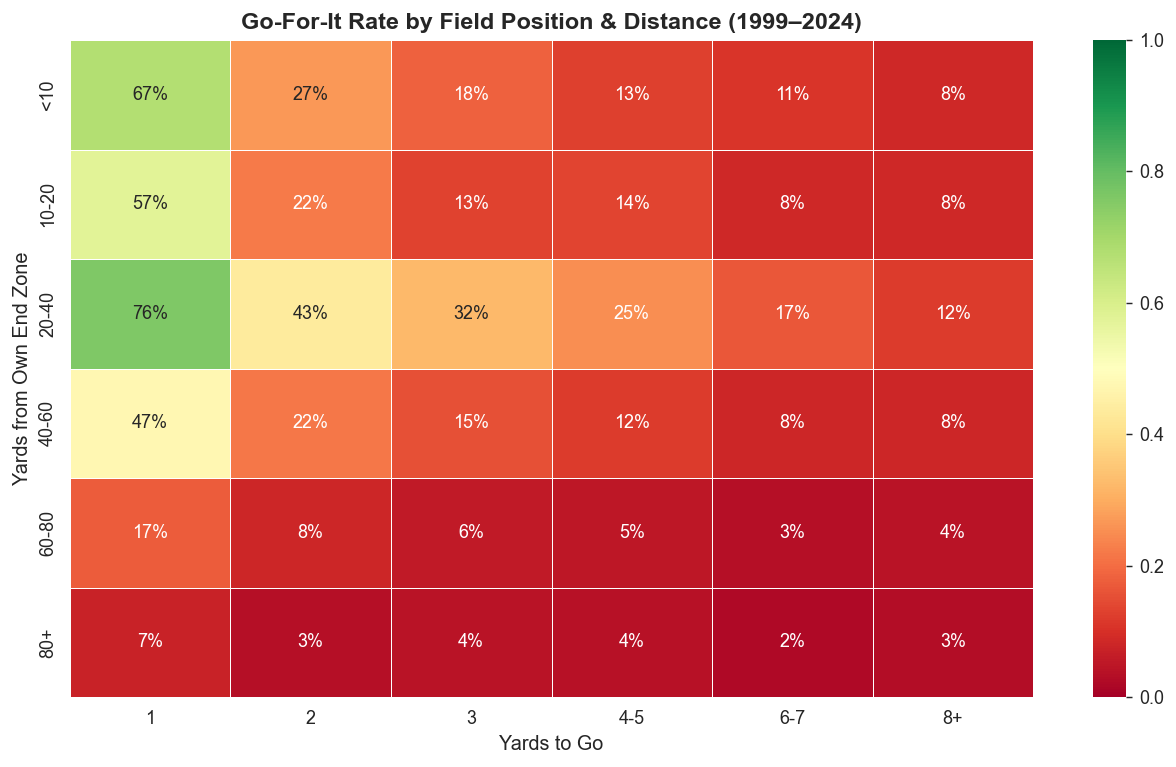

In [5]:
# Heatmap: go-for-it rate by yardline bucket vs ydstogo bucket
fourth['ydstogo_bucket'] = pd.cut(fourth['ydstogo'], bins=[0,1,2,3,5,7,100],
                                   labels=['1','2','3','4-5','6-7','8+'], include_lowest=True)
fourth['yardline_bucket'] = pd.cut(fourth['yardline_100'], bins=[0,10,20,40,60,80,100],
                                    labels=['<10','10-20','20-40','40-60','60-80','80+'],
                                    include_lowest=True)

go_heatmap = (
    fourth[fourth['decision'].isin(['go_for_it','punt','field_goal'])]
    .groupby(['yardline_bucket', 'ydstogo_bucket'])
    ['decision']
    .apply(lambda x: (x == 'go_for_it').mean())
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    go_heatmap,
    annot=True, fmt='.0%', cmap='RdYlGn',
    vmin=0, vmax=1, ax=ax,
    linewidths=0.5,
)
ax.set_title('Go-For-It Rate by Field Position & Distance (1999–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Yards to Go', fontsize=11)
ax.set_ylabel('Yards from Own End Zone', fontsize=11)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}02_go_rate_heatmap.png', bbox_inches='tight')
plt.show()

## 5. WPA Distribution by Decision Type
Key question: does going for it actually produce better WPA outcomes?

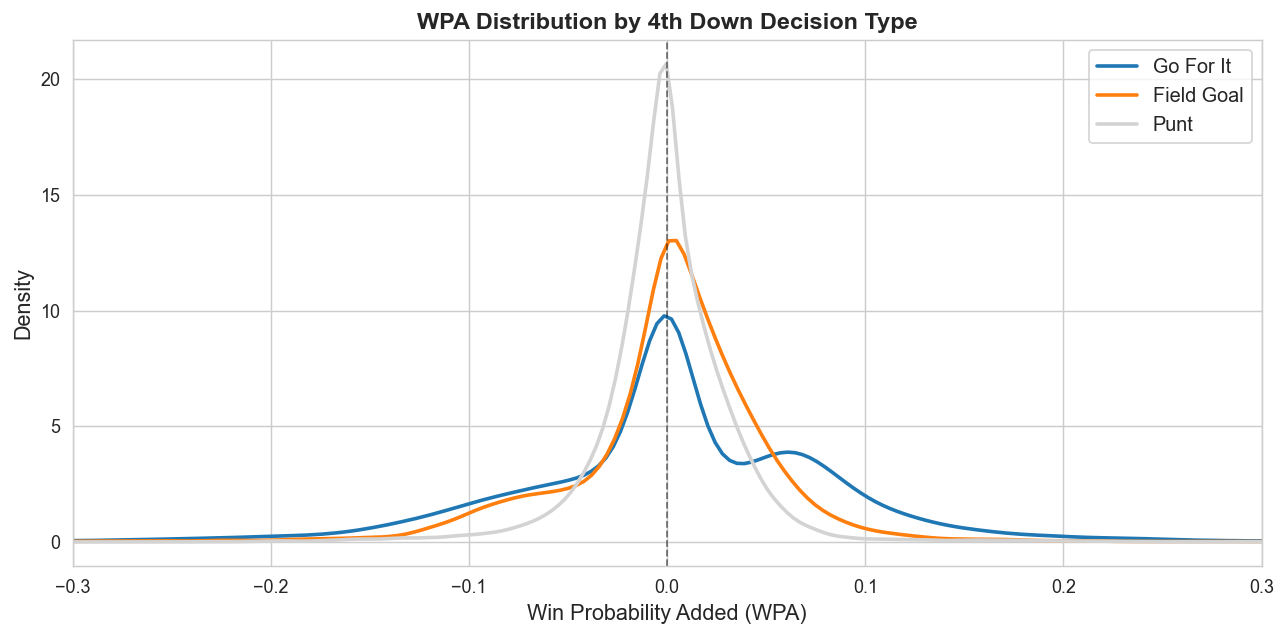


Mean WPA by decision type:
decision
field_goal   -0.0000
go_for_it     0.0047
punt         -0.0001
Name: wpa, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'go_for_it': '#1f77b4', 'field_goal': '#ff7f0e', 'punt': '#d3d3d3'}
for decision, color in colors.items():
    data = fourth[fourth['decision'] == decision]['wpa'].dropna()
    data.plot.kde(ax=ax, label=decision.replace('_', ' ').title(), color=color, linewidth=2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlim(-0.3, 0.3)
ax.set_xlabel('Win Probability Added (WPA)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('WPA Distribution by 4th Down Decision Type', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}03_wpa_by_decision.png', bbox_inches='tight')
plt.show()

# Mean WPA per decision
print('\nMean WPA by decision type:')
print(fourth.groupby('decision')['wpa'].mean().round(4))

## 6. Data Quality Check

In [7]:
print('Null rates in key columns:')
key_cols = ['decision','yardline_100','ydstogo','score_differential',
            'game_seconds_remaining','wp','wpa','epa','spread_line']
for col in key_cols:
    if col in fourth.columns:
        n = fourth[col].isna().sum()
        print(f'  {col:30s}: {n:5,} ({n/len(fourth)*100:.1f}%)')

print(f'\nTotal plays: {len(fourth):,}')
print(f'Seasons: {fourth["season"].min()}–{fourth["season"].max()}')
print(f'Teams: {fourth["posteam"].nunique()}')

Null rates in key columns:
  decision                      :     0 (0.0%)
  yardline_100                  :     0 (0.0%)
  ydstogo                       :     0 (0.0%)
  score_differential            :     0 (0.0%)
  game_seconds_remaining        :     0 (0.0%)
  wp                            :     0 (0.0%)
  wpa                           :    79 (0.1%)
  epa                           :     0 (0.0%)
  spread_line                   :     0 (0.0%)

Total plays: 103,188
Seasons: 1999–2024
Teams: 32


## 7. Save Cleaned Dataset

In [8]:
fourth.to_parquet('../data/fourth_downs_clean.parquet', index=False)
print('Saved to data/fourth_downs_clean.parquet')

Saved to data/fourth_downs_clean.parquet
